# QUESTION 1 (K - MEANS)

DATA: 
       x     y
0  1.90  0.97
1  1.76  0.84
2  2.32  1.63
3  2.31  2.09
4  1.14  2.11
5  5.02  3.02
6  5.74  3.84
7  2.25  3.47
8  4.71  3.60
9  3.17  4.96
DATA SIZE:  10
FINAL CLUSTERS WITH k = 2, {1: [(0.8434782608695651, 0.529126213592233), (1.0, 0.7281553398058253), (0.24130434782608695, 0.6383495145631068), (0.7760869565217391, 0.6699029126213593), (0.44130434782608696, 1.0)], 2: [(0.16521739130434782, 0.03155339805825243), (0.13478260869565217, 0.0), (0.25652173913043474, 0.19174757281553395), (0.25434782608695655, 0.30339805825242716), (0.0, 0.308252427184466)]}

SSE with k = 2, 0.6395729657434988

FINAL CLUSTERS WITH k = 3, {1: [(0.24130434782608695, 0.6383495145631068), (0.44130434782608696, 1.0)], 2: [(0.16521739130434782, 0.03155339805825243), (0.13478260869565217, 0.0), (0.25652173913043474, 0.19174757281553395), (0.25434782608695655, 0.30339805825242716), (0.0, 0.308252427184466)], 3: [(0.8434782608695651, 0.529126213592233), (1.0, 0.7281553398058253), (0.77608695652

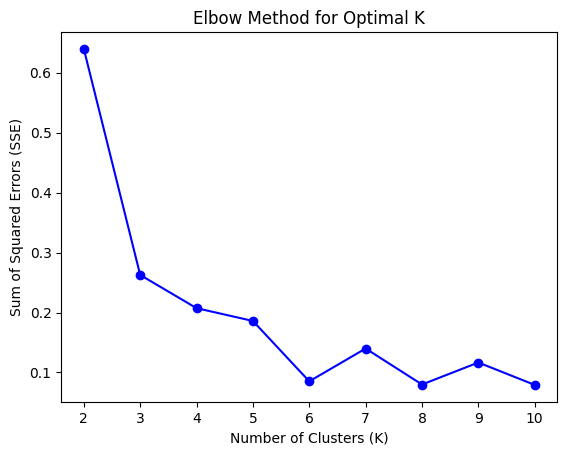

In [164]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

#data
data = {'x': [1.90, 1.76, 2.32, 2.31, 1.14, 5.02, 5.74, 2.25, 4.71, 3.17], 'y': [0.97, 0.84, 1.63, 2.09, 2.11, 3.02, 3.84, 3.47, 3.60, 4.96]}
df = pd.DataFrame(data)
print("DATA: \n", df)
dataSize = df.shape[0]
print("DATA SIZE: ", dataSize)

#min max normalisation
df['x'] = (df['x'] - df['x'].min()) / (df['x'].max() - df['x'].min())
df['y'] = (df['y'] - df['y'].min()) / (df['y'].max() - df['y'].min())      

#final sse
sse = []

#changing clusters
for k in range(2, 11):
    centroids = {}
    clusters = {}

    #initialise new centroids k times
    for cIter in range(1, k + 1):

        x = random.uniform(df['x'].min(), df['x'].max())
        y = random.uniform(df['y'].min(), df['y'].max())
        centroid = (x, y)
        centroids[cIter] = centroid
   

    #update centroids based on no. of iterations
    for costIter in range(10):
        

        #make empty clusters to add points
        for cIter in range(1, k + 1):
            clusters[cIter] = []

        #for each point it is closer to which cluster
        for dataIndexIter in range(dataSize):
            
            
            x = df.iloc[dataIndexIter]['x']
            y = df.iloc[dataIndexIter]['y']
            thisDataPoint = (x, y)
            distances = []

            #get point's distance from all clusters
            for cIter in range(1, k+1):
                thisDataPointDistance = ((((centroids[cIter][0] - thisDataPoint[0]) ** 2 + (centroids[cIter][1] - thisDataPoint[1]) ** 2)) ** 0.5)
                distances.append((thisDataPointDistance, cIter))

            
            
            minimumDistance = min(distances)
            clusters[minimumDistance[1]].append((df.iloc[dataIndexIter, 0], df.iloc[dataIndexIter, 1]))
            

        finalSSE = 0
        for cIter in range(k):
            thisCluster = clusters[cIter + 1]
            thisSSE = 0
            for dataSizeIter in range(len(thisCluster)):
                thisSSE += (((thisCluster[dataSizeIter][0] - centroids[cIter + 1][0]) ** 2) + (thisCluster[dataSizeIter][1] - centroids[cIter + 1][1]) ** 2)
            
            finalSSE += thisSSE

         
        newCentroids = {}

        #k centroids to update
        for cIter in range(k):
            #initialise new centroid
            newCentroids[cIter + 1] = (0, 0)

            #if cluster has atleast one element then update its centroid
            if len(clusters[cIter + 1]) > 0:
                x = 0
                y = 0
                for dataPointSizeIter in range(len(clusters[cIter + 1])):
                    x += clusters[cIter + 1][dataPointSizeIter][0]
                    y += clusters[cIter + 1][dataPointSizeIter][1]
                
                newCentroid = (x / len(clusters[cIter + 1]), y / len(clusters[cIter + 1]))
                newCentroids[cIter + 1] = newCentroid

        centroids = newCentroids
        
    
    finalSSE = 0
    for cIter in range(k):
        thisCluster = clusters[cIter + 1]
        thisSSE = 0
        for dataSizeIter in range(len(thisCluster)):
            thisSSE += (((thisCluster[dataSizeIter][0] - centroids[cIter + 1][0]) ** 2) + (thisCluster[dataSizeIter][1] - centroids[cIter + 1][1]) ** 2)
            
        finalSSE += thisSSE

    sse.append((finalSSE, k))
    print(f"FINAL CLUSTERS WITH k = {k}, {clusters}\n")
    print(f"SSE with k = {k}, {finalSSE}\n")
    
    
print("SSE: ", sse)
sses = [i[0] for i in sse]
ks = [i[1] for i in sse]

plt.plot(ks, sses, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal K')
plt.show()


## In K-mean part, it is seen that the elbow graph is not that smooth due to random initialisation of centroids each time when the cluster size changes.

## Otherwise the method is correct and we can say that because majorly the sse value is decreasing with an increase in the number of clusters

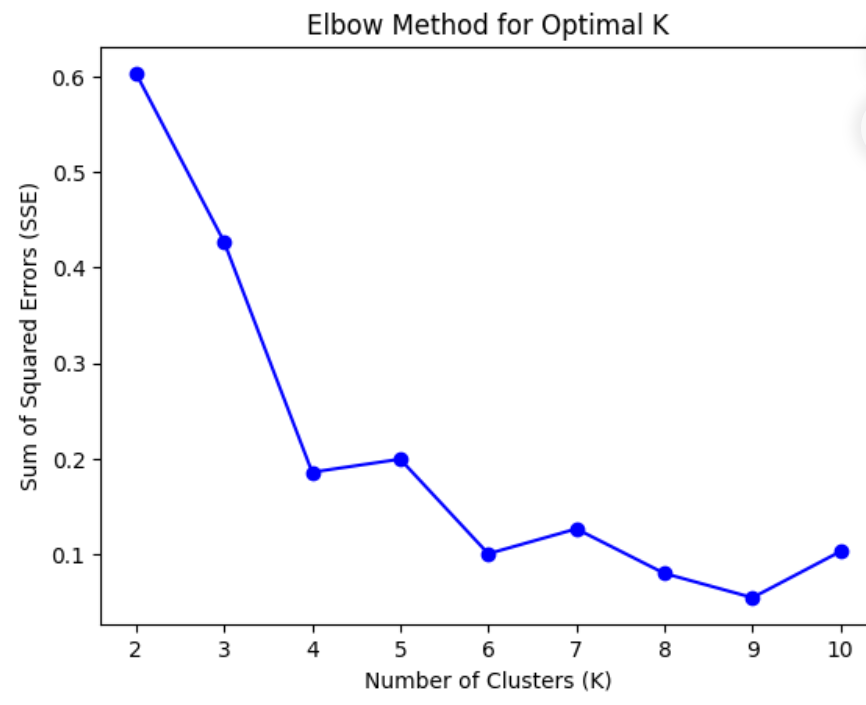

# QUESTION 2 (K - MEDOID)

In [167]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

#data
data = {'x': [1.90, 1.76, 2.32, 2.31, 1.14, 5.02, 5.74, 2.25, 4.71, 3.17], 'y': [0.97, 0.84, 1.63, 2.09, 2.11, 3.02, 3.84, 3.47, 3.60, 4.96]}
df = pd.DataFrame(data)
print("DATA: \n", df)
dataSize = df.shape[0]
print("DATA SIZE: ", dataSize)

#min max normalisation
df['x'] = (df['x'] - df['x'].min()) / (df['x'].max() - df['x'].min())
df['y'] = (df['y'] - df['y'].min()) / (df['y'].max() - df['y'].min())      



finalError = []
#for k number of clusters
for k in range(2, 11):
    
    #final error
    error = float('inf')    
    finalClusters = {}
    finalMedoids = {}

    for iterations in range(50):
        medoids = {}
        clusters = {}
        #generate k mediods from the dataset
        for clusterNo in range(1, k+1):
            medoids[clusterNo] = ((df.iloc[random.randint(0,dataSize-1), 0], df.iloc[random.randint(0,dataSize-1), 1]))
            clusters[clusterNo] = []
        #print(medoids)
        #print(clusters)
    
        #compute distance of each point from the medoid 
        for dataIndexIter in range(dataSize):
                x = df.iloc[dataIndexIter]['x']
                y = df.iloc[dataIndexIter]['y']
            
                thisDataPoint = (x, y)
                distances = []
    
                #get point's distance from all medoids
                for cIter in range(1, k+1):
                    thisDataPointDistance = abs(medoids[cIter][0] - thisDataPoint[0]) + abs(medoids[cIter][1] - thisDataPoint[1])
                    distances.append((thisDataPointDistance, cIter))
    
                
                minimumDistance = min(distances)
                clusters[minimumDistance[1]].append((df.iloc[dataIndexIter, 0], df.iloc[dataIndexIter, 1]))
        #print(clusters)
    
    
        thisClusterError = 0
    
        #compute the error of each of cluster
        for clusterNo in range(1, k+1):
            if len(clusters[clusterNo]) > 0:
                    for dataPointSizeIter in range(len(clusters[clusterNo])):
                        thisClusterError += abs(medoids[clusterNo][0] - df.iloc[dataPointSizeIter, 0]) + abs(medoids[clusterNo][1] - df.iloc[dataPointSizeIter, 1])
    
            
        #print(thisClusterError)
        #print(error)
        if(thisClusterError < error):
            error = thisClusterError
            finalClusters = clusters
            finalMedoids = medoids
            #print("updated")
                
        
    print(f"WHEN K = {k}")
    print(medoids)
    print(f"FINAL CLUSTERS WHEN K = {k}, {finalClusters}")
    print(error, "\n\n")
    finalError.append((error, k))

print(finalError)

'''errors = [i[0] for i in finalError]
ks = [i[1] for i in finalError]
plt.plot(ks, errors, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Errors')
plt.title('Elbow Method for Optimal K')
plt.show()'''
    
    

DATA: 
       x     y
0  1.90  0.97
1  1.76  0.84
2  2.32  1.63
3  2.31  2.09
4  1.14  2.11
5  5.02  3.02
6  5.74  3.84
7  2.25  3.47
8  4.71  3.60
9  3.17  4.96
DATA SIZE:  10
WHEN K = 2
{1: (0.0, 0.6383495145631068), 2: (0.25434782608695655, 0.19174757281553395)}
FINAL CLUSTERS WHEN K = 2, {1: [(0.16521739130434782, 0.03155339805825243), (0.13478260869565217, 0.0), (0.25652173913043474, 0.19174757281553395), (0.25434782608695655, 0.30339805825242716), (0.0, 0.308252427184466), (0.24130434782608695, 0.6383495145631068)], 2: [(0.8434782608695651, 0.529126213592233), (1.0, 0.7281553398058253), (0.7760869565217391, 0.6699029126213593), (0.44130434782608696, 1.0)]}
3.7101519628535247 


WHEN K = 3
{1: (1.0, 1.0), 2: (0.8434782608695651, 0.308252427184466), 3: (0.25434782608695655, 0.19174757281553395)}
FINAL CLUSTERS WHEN K = 3, {1: [(0.8434782608695651, 0.529126213592233), (1.0, 0.7281553398058253), (0.24130434782608695, 0.6383495145631068), (0.7760869565217391, 0.6699029126213593), (0.4

"errors = [i[0] for i in finalError]\nks = [i[1] for i in finalError]\nplt.plot(ks, errors, marker='o', linestyle='-', color='b')\nplt.xlabel('Number of Clusters (K)')\nplt.ylabel('Errors')\nplt.title('Elbow Method for Optimal K')\nplt.show()"

# COMPARISON

### In my opinion, K-means performed far better because it converged faster with only max 10 iterations needed whereas K-medoids used 50 iterations. Moreoever, the minimum error seen was far less than that of the case of the K-medoid. K medoid is found to be having more computational cost!